In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [139]:
df = pd.read_csv('cardekho.csv')

In [140]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [141]:
df.shape

(15411, 14)

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  str    
 2   brand              15411 non-null  str    
 3   model              15411 non-null  str    
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  str    
 7   fuel_type          15411 non-null  str    
 8   transmission_type  15411 non-null  str    
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), str(6)
memory usage: 1.6 MB


In [143]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [144]:
df.describe(include='object')

,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


In [145]:
df['brand'].nunique()

32

In [146]:
df['model'].nunique()

120

In [147]:
df.drop(columns=['Unnamed: 0', 'car_name', 'model'], inplace=True)

In [148]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [149]:
df.isnull().sum()

brand                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [150]:
# df.dropna(inplace=True)

In [151]:
df.drop_duplicates(inplace=True)

In [152]:
df.shape

(15243, 11)

In [153]:
Q1 = df['selling_price'].quantile(0.01)
Q3 = df['selling_price'].quantile(0.99)

before = len(df)
df = df[(df['selling_price'] >= Q1) & (df['selling_price'] <= Q3)]
after = len(df)

print(f"Rows before removing outliets: {before}")
print(f"Rows after removing outliets: {after}")
print(f"Removed :  {before - after} outlier rows")

Rows before removing outliets: 15243
Rows after removing outliets: 14957
Removed :  286 outlier rows


In [154]:
plt.figure(figsize=(10,6))
sns.histplot(df['selling_price'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of selling price")
plt.xlabel("Selling price")
plt.ylabel("Frequency")
# plt.show()

plt.tight_layout()
plt.savefig("plt1_selling_price_distribution.png")
plt.close()

In [155]:
df.dtypes

brand                    str
vehicle_age            int64
km_driven              int64
seller_type              str
fuel_type                str
transmission_type        str
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [156]:
avg_price = df.groupby('fuel_type')['selling_price'].mean()

In [157]:
avg_price

fuel_type
CNG         4.176890e+05
Diesel      9.238101e+05
Electric    1.853500e+06
LPG         2.236053e+05
Petrol      5.385508e+05
Name: selling_price, dtype: float64

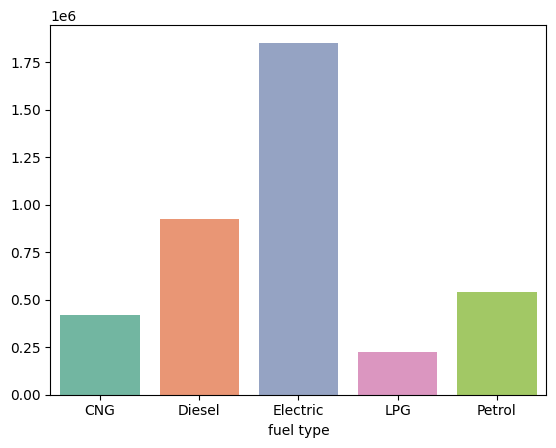

In [158]:
sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='Set2'
)

plt.title("")
plt.xlabel("fuel type")
plt.ylabel("")
plt.show()

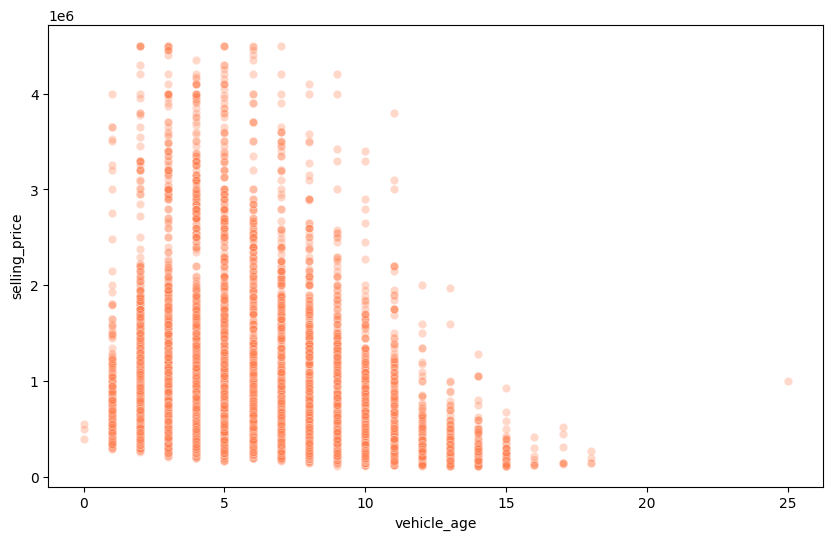

In [159]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='vehicle_age',
    y='selling_price',
    data=df,
    alpha=0.3,
    color='coral'
)
plt.show()

In [160]:
df[['vehicle_age','selling_price']].corr

<bound method DataFrame.corr of        vehicle_age  selling_price
0                9         120000
1                5         550000
2               11         215000
3                9         226000
4                6         570000
...            ...            ...
15406            9         250000
15407            2         925000
15408            6         425000
15409            5        1225000
15410            2        1200000

[14957 rows x 2 columns]>

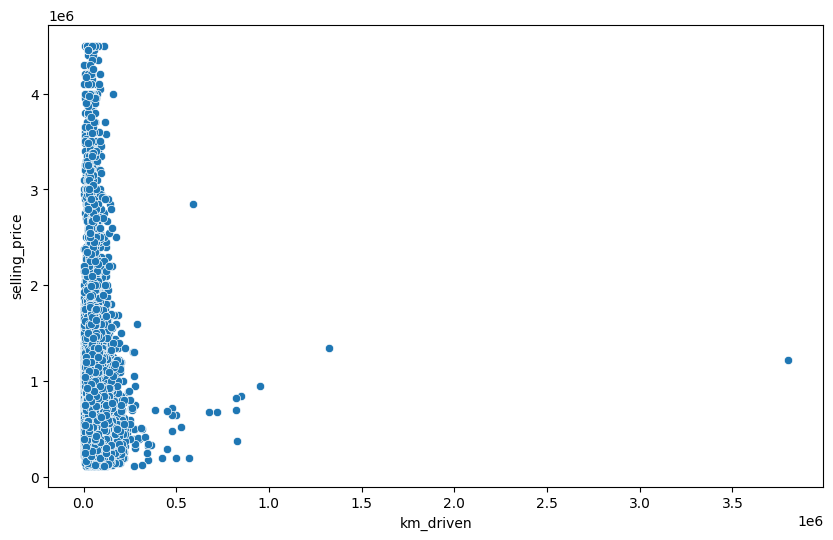

In [161]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='km_driven',
    y='selling_price',
    data=df,
)
plt.show()

In [162]:
numeric_cols = df.select_dtypes(include=[np.number])

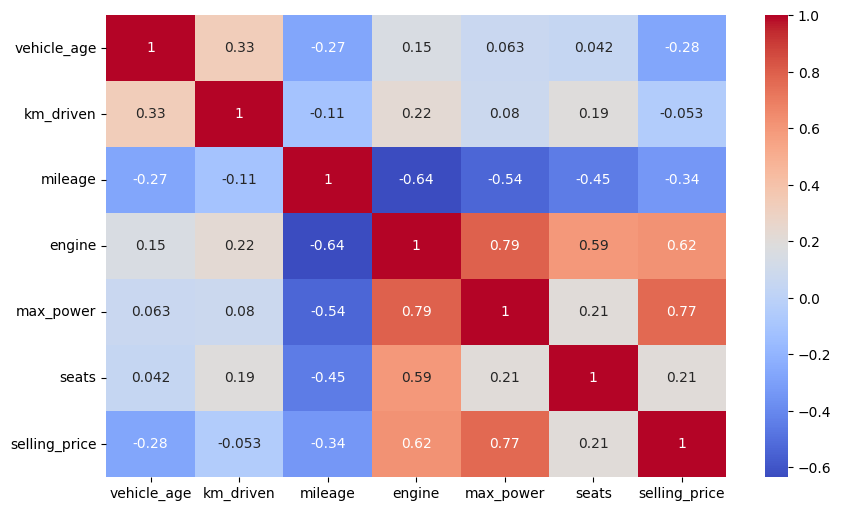

In [163]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(),annot=True, cmap="coolwarm")
plt.show()


In [164]:
cat_cols = ['brand','seller_type','fuel_type','transmission_type']
cat_cols

['brand', 'seller_type', 'fuel_type', 'transmission_type']

In [165]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded {col} with LabelEncoder")

Encoded brand with LabelEncoder
Encoded seller_type with LabelEncoder
Encoded fuel_type with LabelEncoder
Encoded transmission_type with LabelEncoder


In [166]:
df['price_per_km'] = df['selling_price'] / (df['km_driven'] + 1)

In [167]:
df.head()

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,price_per_km
0,16,9,120000,1,4,1,19.70,796,46.30,5,120000,0.999992
1,6,5,20000,1,4,1,18.90,1197,82.00,5,550000,27.498625
2,6,11,60000,1,4,1,17.00,1197,80.00,5,215000,3.583274
3,16,9,37000,1,4,1,20.92,998,67.10,5,226000,6.107943
4,4,6,30000,0,1,1,22.77,1498,98.59,5,570000,18.999367


In [168]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [169]:
X = X.drop(columns=['price_per_km'])

In [170]:
X.shape

(14957, 10)

In [171]:
y.shape

(14957,)

In [172]:
X.columns.tolist()

['brand',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats']

In [173]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [174]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [175]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

<Axes: >

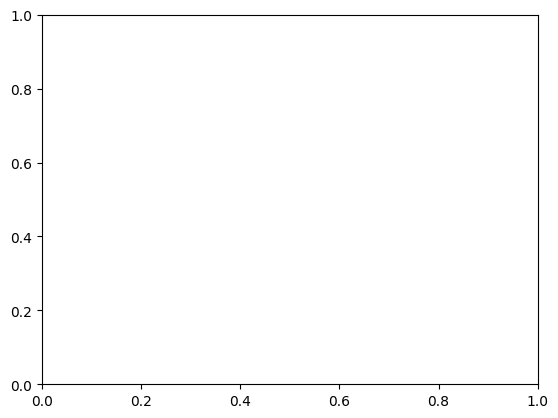

In [176]:
sns.scatterplot(
    
)

In [177]:
importances = model.feature_importances_
feat_names = X.columns.tolist()
sorted_idx = np.argsort(importances)[::-1]

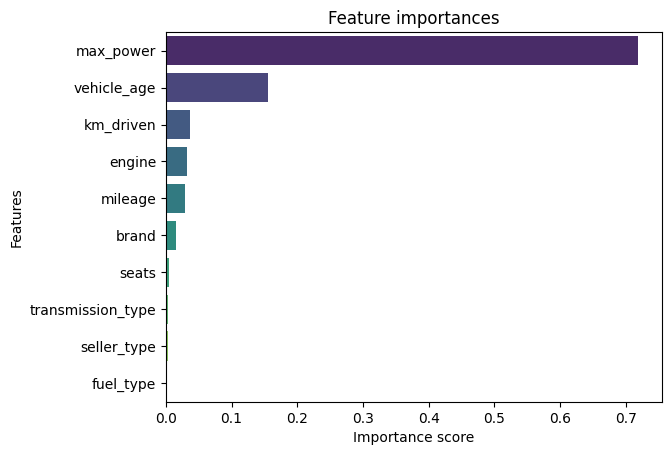

In [178]:
sns.barplot(
    x=importances[sorted_idx],
    y=np.array(feat_names)[sorted_idx],
    palette='viridis'
)

plt.title("Feature importances")
plt.xlabel("Importance score")
plt.ylabel("Features")
plt.show()

In [179]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator= RandomForestRegressor(random_state=42),
    param_grid= param_grid,
    cv= 3,
    n_jobs= -1,
    verbose=1
)

In [180]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_

In [181]:
best_model = grid_search.best_estimator_
y_pred_best = grid_search.best_score_
mae_best = mean_squared_error(y_test, y_pred)
rmse_best = np.sqrt(mean_squared_error(y_pred, y_test))
r2_best = r2_score(y_pred, y_test)

print(f"Best Model Mean Absolute Error (MAE): {mae_best:.2f}")
print(f"Best Model Root Mean Squared Error (RMSE): {rmse_best:.2f}")
print(f"Best Model R-squared (R2): {r2_best:.4f}")

Best Model Mean Absolute Error (MAE): 25505929990.48
Best Model Root Mean Squared Error (RMSE): 159705.76
Best Model R-squared (R2): 0.9189


In [182]:
model_comparisons = pd.DataFrame({
    'Model': ['Initial Model', 'Best Model'],
    'MAE': [mae, mae_best],
    'RMSE': [rmse, rmse_best],
    'R2': [r2, r2_best]
})
model_comparisons

,Model,MAE,RMSE,R2
0,Initial Model,9.245740e+04,159705.760668,0.923950
1,Best Model,2.550593e+10,159705.760668,0.918867


In [183]:
joblib.dump(best_model, 'best_car_price_model.pkl')
print("Saved the best model to 'best_car_price_model.pkl' for future use.")

Saved the best model to 'best_car_price_model.pkl' for future use.


In [184]:
loaded_model = joblib.load('best_car_price_model.pkl')

In [185]:
loaded_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [186]:
X.columns.tolist()

['brand',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats']

In [187]:
new_car = pd.DataFrame({
    'brand' : [0],
    'vehicle_age' : [5],
    'km_driven' : [50000],
    'seller_type' : [1],
    'fuel_type' : [2],
    'transmission_type' : [1],
    'mileage' : [18.0],
    'engine' : [1500],
    'max_power' : [100],
    'seats' : [5]
})
new_car

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,5,50000,1,2,1,18.0,1500,100,5


In [188]:
predicted_price = loaded_model.predict(new_car)
print('New Car details:', new_car.to_string(index=False))
print(f'Predicted Selling Price for the new car: {predicted_price[0]:.2f}')

New Car details:  brand  vehicle_age  km_driven  seller_type  fuel_type  transmission_type  mileage  engine  max_power  seats
     0            5      50000            1          2                  1     18.0    1500        100      5
Predicted Selling Price for the new car: 658647.84
